# Imports and opening the files

In [1]:
#libs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import os
import openpyxl
import csv
import sys
import re
import torch
from transformers import AutoTokenizer, AutoModel
from tqdm.notebook import tqdm


In [ ]:
csv.field_size_limit(10**7)

# Load in chunks, process each chunk, discard raw text after
results = []
for chunk in pd.read_csv(r"..\data\Newspapers_1.csv", encoding="utf-8", 
                          engine="python", chunksize=500):
    # do your processing here on each chunk, e.g. extract keywords
    results.append(chunk)

news1_df = pd.concat(results, ignore_index=True)

: 

In [ ]:
# Load in chunks, process each chunk, discard raw text after
results = []
for chunk in pd.read_csv(r"..\data\Newspapers_2.csv", encoding="utf-8", 
                          engine="python", chunksize=500):
    # do your processing here on each chunk, e.g. extract keywords
    results.append(chunk)

news2_df = pd.concat(results, ignore_index=True)

: 

In [ ]:
bonds_df = pd.read_excel(r"..\data\Greece_Germany_Bond_Spread_2010_2026.xlsx")

: 

In [ ]:
news1_df.head()

,original_url,final_url,word_count,status,error,date,date_raw,heading_type,article_title,content,extraction_method
0,https://www.capital.gr/diethni/3976815/souidia...,https://www.capital.gr/diethni/3976815/souidia...,148.0,success,NaN,2026-02-26 22:20,"Πέμπτη, 26-Φεβ-2026 22:20",ΔΙΕΘΝΗ,"Drone, πιθανότατα ρωσικό, εντοπίστηκε κοντά στ...",Ένα μη επανδρωμένο αεροσκάφος που εντοπίστηκε ...,readability
1,https://www.capital.gr/diethni/3976810/kouba-o...,https://www.capital.gr/diethni/3976810/kouba-o...,304.0,success,NaN,2026-02-26 21:58,"Πέμπτη, 26-Φεβ-2026 21:58",ΔΙΕΘΝΗ,Ο ένας από τους τέσσερις άνδρες που σκοτώθηκαν...,Ένας από τους τέσσερις άνδρες που σκοτώθηκαν σ...,readability
2,https://www.capital.gr/diethni/3976808/amerika...,https://www.capital.gr/diethni/3976808/amerika...,259.0,success,NaN,2026-02-26 21:39,"Πέμπτη, 26-Φεβ-2026 21:39",ΔΙΕΘΝΗ,Αμερικανοί αξιωματούχοι συναντήθηκαν με τον εγ...,"Αμερικανοί αξιωματούχοι, συνεργάτες του υπουργ...",readability
3,https://www.capital.gr/diethni/3976806/instagr...,https://www.capital.gr/diethni/3976806/instagr...,310.0,success,NaN,2026-02-26 21:28,"Πέμπτη, 26-Φεβ-2026 21:28",ΔΙΕΘΝΗ,Θα ενημερώνει τους γονείς αν το παιδί τους εμφ...,Το Instagram θα προειδοποιεί τους γονείς που έ...,readability
4,https://www.capital.gr/politiki/3976802/k-tsou...,https://www.capital.gr/politiki/3976802/k-tsou...,173.0,success,NaN,2026-02-26 20:58,"Πέμπτη, 26-Φεβ-2026 20:58",ΠΟΛΙΤΙΚΗ,"""Ο κ. Μαρινάκης, πριν ρωτήσει ξανά αν η αντιπο...","Ο εκπρόσωπος Τύπου του ΠΑΣΟΚ-ΚΙΝΑΛ, Κώστας Τσο...",readability


: 

In [ ]:
news2_df.head()

,original_url,final_url,word_count,status,error,date,date_raw,heading_type,article_title,content,extraction_method
0,https://www.capital.gr/diethni/3976812/stis-ar...,https://www.capital.gr/diethni/3976812/stis-ar...,143.0,success,NaN,2026-02-26 22:06,"Πέμπτη, 26-Φεβ-2026 22:06",ΔΙΕΘΝΗ,Στις αρχές Μαρτίου στα Εμιράτα η νέα τριμερής ...,Ο επόμενος γύρος των τριμερών ειρηνευτικών δια...,readability
1,https://www.capital.gr/agores/3976809/mikres-m...,https://www.capital.gr/agores/3976809/mikres-m...,282.0,success,NaN,2026-02-26 21:42,"Πέμπτη, 26-Φεβ-2026 21:42",ΑΓΟΡΕΣ,Μικρές μεταβολές ο χρυσός με το βλέμμα στις συ...,Οι τιμές του χρυσού παρέμειναν σχεδόν αμετάβλη...,readability
2,https://www.capital.gr/diethni/3976807/sunanti...,https://www.capital.gr/diethni/3976807/sunanti...,800.0,success,NaN,2026-02-26 21:33,"Πέμπτη, 26-Φεβ-2026 21:33",ΔΙΕΘΝΗ,"Μελόνι: ""Ιταλία και Κύπρος ανήκουν σε έναν...",Ο Κύπριος πρόεδρος Νίκος Χριστοδουλίδης είχε σ...,readability
3,https://www.capital.gr/diethni/3976805/sugkrou...,https://www.capital.gr/diethni/3976805/sugkrou...,224.0,success,NaN,2026-02-26 21:20,"Πέμπτη, 26-Φεβ-2026 21:20",ΔΙΕΘΝΗ,Συγκρούσεις στα σύνορα Πακιστάν - Αφγανιστάν,Οι αρχές των Ταλιμπάν δήλωσαν σήμερα ότι ο αφγ...,readability
4,https://www.capital.gr/diethni/3976801/ipa-ira...,https://www.capital.gr/diethni/3976801/ipa-ira...,220.0,success,NaN,2026-02-26 20:52,"Πέμπτη, 26-Φεβ-2026 20:52",ΔΙΕΘΝΗ,"Ολοκληρώθηκαν οι διαπραγματεύσεις με ""σημαντικ...",Οι διαπραγματεύσεις μεταξύ του Ιράν και των ΗΠ...,readability


: 

In [ ]:
bonds_df.head()

,Date,Spread
0,03/01/2026,0.7377
1,02/22/2026,0.6483
2,02/15/2026,0.6095
3,02/08/2026,0.6077
4,02/01/2026,0.6104


: 

# Preprocessing

In [2]:
# Combine both newspaper datasets
df = pd.concat([news1_df, news2_df], ignore_index=True)
# Compute char length
df["char_count"] = df['content'].str.len()

df = df.reset_index(drop=True)
print(f"Total articles: {len(df)}")
df.head()

NameError: name 'news1_df' is not defined

In [ ]:
# Check for missing values across all columns
print("=" * 35)
print(f"{'Column':<20} {'NaN Count':>10}")
print("=" * 35)
for col in df.columns:
    print(f"{col:<20} {df[col].isna().sum():>10}")
print("=" * 35)


Column                NaN Count
original_url                  0
final_url                     0
word_count               382862
status                        0
error                   1566371
date                          0
date_raw                 382862
heading_type             369298
article_title                 2
content                       0
extraction_method             0
char_count                    0


: 

: 

In [ ]:
# Distribution of status values
print("=" * 35)
print(f"{'Status':<20} {'Count':>10}")
print("=" * 35)
for status, count in df["status"].value_counts().items():
    print(f"{status:<20} {count:>10}")
print("=" * 35)


Status                    Count
success                 1566371


: 

: 

In [ ]:
# Distribution of heading types
counts = df["heading_type"].value_counts()
print(f"Total unique heading types: {len(counts)}")
print("=" * 40)
print(f"{'Heading Type':<25} {'Count':>10}")
print("=" * 40)
for heading, count in counts.head(80).items():
    print(f"{heading:<25} {count:>10}")
print("=" * 40)


Total unique heading types: 164
Heading Type                   Count
ΔΙΕΘΝΗ                        230510
ΕΠΙΚΑΙΡΟΤΗΤΑ                  221847
VIDEO_NEWS                    177551
ΟΙΚΟΝΟΜΙΑ                     141472
ΕΠΙΧΕΙΡΗΣΕΙΣ                  113014
ΧΡΗΜ. ΑΝΑΚΟΙΝΩΣΕΙΣ             96891
ΠΟΛΙΤΙΚΗ                       68609
ΑΓΟΡΕΣ                         53309
CAPITALHEALTH                   7201
BRAND VOICE                     5804
ΜΕ ΑΠΟΨΗ                        5782
ΑΡΘΡΑ                           5106
ΠΙΣΩ ΑΠΟ ΤΙΣ ΓΡΑΜΜΕΣ            4906
ΚΩΣΤΑΣ ΣΤΟΥΠΑΣ                  4749
FOREX                           4566
CAPITALTV                       4010
Ο ΓΙΩΡΓΟΣ ΚΡΑΛΟΓΛΟΥ ΓΡΑΦΕΙ       3077
BLOOMBERG OPINION               2967
ΠΑΡΟΥΣΙΑΣΕΙΣ                    2864
ΤΕΧΝΟΛΟΓΙΑ                      2541
ΕΡΕΥΝΕΣ                         2123
REAL ESTATE - ΕΙΔΗΣΕΙΣ          1882
ΕΤΑΙΡΙΚΗ ΚΟΙΝΩΝΙΚΗ ΕΥΘΥΝΗ       1710
CAPITALTECH: INTERNET           1702
Ο ΠΕΤΡΟΣ ΛΑΖΟΣ ΓΡΑΦΕΙ           1650
THINK

: 

: 

In [ ]:
df = df.drop(columns=['original_url', 'final_url', 'status', 'error', 'date_raw', 'extraction_method'])

: 

: 

In [ ]:
df.head()

,word_count,date,heading_type,article_title,content,char_count
0,148.0,2026-02-26 22:20,ΔΙΕΘΝΗ,"Drone, πιθανότατα ρωσικό, εντοπίστηκε κοντά στ...",Ένα μη επανδρωμένο αεροσκάφος που εντοπίστηκε ...,1003
1,304.0,2026-02-26 21:58,ΔΙΕΘΝΗ,Ο ένας από τους τέσσερις άνδρες που σκοτώθηκαν...,Ένας από τους τέσσερις άνδρες που σκοτώθηκαν σ...,1978
2,259.0,2026-02-26 21:39,ΔΙΕΘΝΗ,Αμερικανοί αξιωματούχοι συναντήθηκαν με τον εγ...,"Αμερικανοί αξιωματούχοι, συνεργάτες του υπουργ...",1800
3,310.0,2026-02-26 21:28,ΔΙΕΘΝΗ,Θα ενημερώνει τους γονείς αν το παιδί τους εμφ...,Το Instagram θα προειδοποιεί τους γονείς που έ...,2015
4,173.0,2026-02-26 20:58,ΠΟΛΙΤΙΚΗ,"""Ο κ. Μαρινάκης, πριν ρωτήσει ξανά αν η αντιπο...","Ο εκπρόσωπος Τύπου του ΠΑΣΟΚ-ΚΙΝΑΛ, Κώστας Τσο...",1266


: 

: 

In [ ]:
patterns = df['date'].astype(str).apply(lambda x: re.sub(r'\d', '#', x))
print(patterns.value_counts().to_string())

date
####-##-## ##:##       1183934
####-##-## ##:##:##     334997
####-##-##               47391
##:####/##                  49


: 

: 

In [ ]:
for pattern, group in df.groupby(df['date'].astype(str).apply(lambda x: re.sub(r'\d', '#', x))):
    print(f"{pattern}  →  {group['date'].iloc[0]}")

####-##-##  →  2002-05-16
####-##-## ##:##  →  2026-02-26 22:20
####-##-## ##:##:##  →  2004-07-02 15:39:00
##:####/##  →  23:5926/02


: 

: 

In [ ]:
# Drop malformed
mask_bad = df['date'].astype(str).str.match(r'^\d{2}:\d{4}/\d{2}')
df = df[~mask_bad].reset_index(drop=True)

# Keep only first 10 chars (YYYY-MM-DD)
df['date'] = df['date'].astype(str).str[:10]

: 

: 

There cannot be a date where tehre is 1 and not 01 because the whole date would be less character and with a check we would catch them, since its zero, tehre isnt a value. 

In [ ]:
# Validate date components for hallucinating values
date_parts = df['date'].astype(str).str.extract(r'(\d{2})/(\d{2})/(\d{4})')
date_parts.columns = ['month', 'day', 'year']
date_parts = date_parts.astype(float)

print("Date Component Validation")
print("=" * 40)
print(f"{'Year':<10} min: {date_parts['year'].min():.0f}   max: {date_parts['year'].max():.0f}")
print(f"{'Month':<10} min: {date_parts['month'].min():.0f}   max: {date_parts['month'].max():.0f}   (valid: 1-12)")
print(f"{'Day':<10} min: {date_parts['day'].min():.0f}   max: {date_parts['day'].max():.0f}   (valid: 1-31)")
print("=" * 40)
print(f"{'Month > 12:':<20} {(date_parts['month'] > 12).sum():>10}")
print(f"{'Day > 31:':<20} {(date_parts['day'] > 31).sum():>10}")
print(f"{'Month == 0:':<20} {(date_parts['month'] == 0).sum():>10}")
print(f"{'Day == 0:':<20} {(date_parts['day'] == 0).sum():>10}")
print("=" * 40)


Date Component Validation
Year       min: nan   max: nan
Month      min: nan   max: nan   (valid: 1-12)
Day        min: nan   max: nan   (valid: 1-31)
Month > 12:                   0
Day > 31:                     0
Month == 0:                   0
Day == 0:                     0


: 

: 

In [ ]:
# Check for malformed short dates
short = df[df['date'].str.len() < 10]['date']
print("=" * 35)
print(f"{'Dates shorter than 10 chars:':<28} {len(short):>5}")
print("=" * 35)
if len(short) > 0:
    print(f"{'Value':<20} {'Count':>10}")
    print("-" * 35)
    print(short.value_counts().to_string())
print("=" * 35)


Dates shorter than 10 chars:     0


: 

: 

In [ ]:
# Convert and validate date format (MM/DD/YYYY)
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d', errors='coerce').dt.strftime('%m/%d/%Y')

print("Date Validation")
print("=" * 30)
print(f"{'NaN / NaT:':<15} {df['date'].isna().sum():>10}")
print(f"{'nan string:':<15} {(df['date'] == 'nan').sum():>10}")
print(f"{'empty string:':<15} {(df['date'] == '').sum():>10}")
print(f"{'len != 10:':<15} {(df['date'].str.len() != 10).sum():>10}")
print("=" * 30)
print(f"\nSample:\n{df['date'].head(5).to_string()}")


Date Validation
NaN / NaT:               0
nan string:              0
empty string:            0
len != 10:               0

Sample:
0    02/26/2026
1    02/26/2026
2    02/26/2026
3    02/26/2026
4    02/26/2026


: 

: 

In [ ]:
df.head()

,word_count,date,heading_type,article_title,content,char_count
0,148.0,02/26/2026,ΔΙΕΘΝΗ,"Drone, πιθανότατα ρωσικό, εντοπίστηκε κοντά στ...",Ένα μη επανδρωμένο αεροσκάφος που εντοπίστηκε ...,1003
1,304.0,02/26/2026,ΔΙΕΘΝΗ,Ο ένας από τους τέσσερις άνδρες που σκοτώθηκαν...,Ένας από τους τέσσερις άνδρες που σκοτώθηκαν σ...,1978
2,259.0,02/26/2026,ΔΙΕΘΝΗ,Αμερικανοί αξιωματούχοι συναντήθηκαν με τον εγ...,"Αμερικανοί αξιωματούχοι, συνεργάτες του υπουργ...",1800
3,310.0,02/26/2026,ΔΙΕΘΝΗ,Θα ενημερώνει τους γονείς αν το παιδί τους εμφ...,Το Instagram θα προειδοποιεί τους γονείς που έ...,2015
4,173.0,02/26/2026,ΠΟΛΙΤΙΚΗ,"""Ο κ. Μαρινάκης, πριν ρωτήσει ξανά αν η αντιπο...","Ο εκπρόσωπος Τύπου του ΠΑΣΟΚ-ΚΙΝΑΛ, Κώστας Τσο...",1266


: 

: 

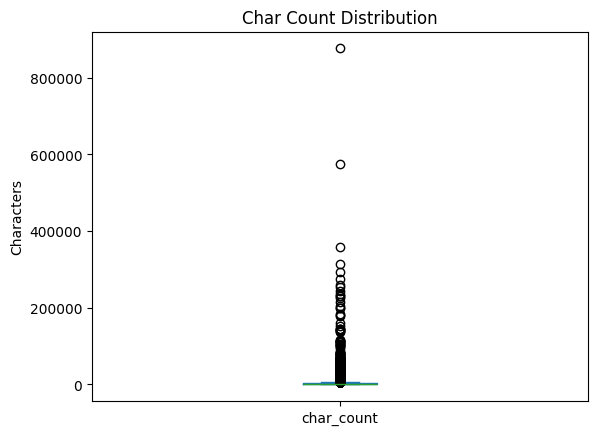

: 

: 

In [ ]:
df['char_count'].plot(kind='box', title='Char Count Distribution')
plt.ylabel('Characters')
plt.show()

In [ ]:
df["char_count"].describe()

count    1.566322e+06
mean     1.926623e+03
std      2.548777e+03
min      2.500000e+01
25%      5.200000e+02
50%      1.255000e+03
75%      2.573000e+03
max      8.769860e+05
Name: char_count, dtype: float64

: 

: 

In [ ]:
# Percentage of articles below each character count threshold
print("=" * 35)
print(f"{'Threshold':<15} {'% of Articles':>15}")
print("=" * 35)
for threshold in [5000, 6000, 7000, 8000, 9000, 10000]:
    pct = (df['char_count'] < threshold).sum() / len(df) * 100
    print(f"< {threshold:>6} chars   {pct:>12.1f}%")
print("=" * 35)


Threshold         % of Articles
<   5000 chars           92.8%
<   6000 chars           95.5%
<   7000 chars           97.0%
<   8000 chars           97.9%
<   9000 chars           98.5%
<  10000 chars           98.9%


: 

: 

In [ ]:
# Truncate content to 5000 chars and update char_count
df['content'] = df['content'].str[:5000]
df['char_count'] = df['content'].str.len()

: 

: 

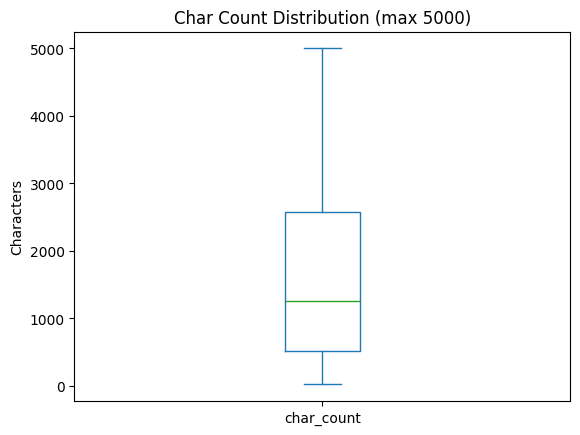

: 

: 

In [ ]:
df['char_count'].plot(kind='box', title='Char Count Distribution (max 5000)')
plt.ylabel('Characters')
plt.show()

In [ ]:
for cat in df['heading_type'].value_counts().index:
    print(cat)


ΔΙΕΘΝΗ
ΕΠΙΚΑΙΡΟΤΗΤΑ
VIDEO_NEWS
ΟΙΚΟΝΟΜΙΑ
ΕΠΙΧΕΙΡΗΣΕΙΣ
ΧΡΗΜ. ΑΝΑΚΟΙΝΩΣΕΙΣ
ΠΟΛΙΤΙΚΗ
ΑΓΟΡΕΣ
CAPITALHEALTH
BRAND VOICE
ΜΕ ΑΠΟΨΗ
ΑΡΘΡΑ
ΠΙΣΩ ΑΠΟ ΤΙΣ ΓΡΑΜΜΕΣ
ΚΩΣΤΑΣ ΣΤΟΥΠΑΣ
FOREX
CAPITALTV
Ο ΓΙΩΡΓΟΣ ΚΡΑΛΟΓΛΟΥ ΓΡΑΦΕΙ
BLOOMBERG OPINION
ΠΑΡΟΥΣΙΑΣΕΙΣ
ΤΕΧΝΟΛΟΓΙΑ
ΕΡΕΥΝΕΣ
REAL ESTATE - ΕΙΔΗΣΕΙΣ
ΕΤΑΙΡΙΚΗ ΚΟΙΝΩΝΙΚΗ ΕΥΘΥΝΗ
CAPITALTECH: INTERNET
Ο ΠΕΤΡΟΣ ΛΑΖΟΣ ΓΡΑΦΕΙ
THINK TANK
BUSINESSWEEK ONLINE
CAPITALTECH: ΨΥΧΑΓΩΓΙΑ
ENGLISH
Ο ΔΗΜΗΤΡΗΣ ΠΑΠΑΚΩΝΣΤΑΝΤΙΝΟΥ ΓΡΑΦΕΙ
ΑΓΟΡΑ ΑΥΤΟΚΙΝΗΤΟΥ
ΑΝΑΛΥΣΗ
CAPITAL LOGISTIS
ΔΙΑΤΡΟΦΗ
ΣΙΩΠΗΤΗΡΙΟ
Εκλογες Σεπτεμβριος 2015
DELPHI ECONOMIC FORUM
BREXIT
CAPITALTECH: SOFTWARE
IN THE MONEY
ΣΥΝΕΝΤΕΥΞΕΙΣ
ΕΥΕΞΙΑ
ΑΚΙΝΗΤΑ
ΧΡΗΣΤΟΣ ΧΩΜΕΝΙΔΗΣ
ΝΕΕΣ ΘΕΡΑΠΕΙΕΣ
ΦΟΡΟΑΠΟΨΕΙΣ
ΔΗΜΟΤΙΚΕΣ ΕΚΛΟΓΕΣ
ΑΓΩΝΕΣ
EUROBASKET 2017
TRAVEL
ΔΟΚΙΜΕΣ
TAX: ΕΠΙΧΕΙΡ/ΕΛ.ΕΠΑΓΓ.
ΓΑΛΛΙΑ ΕΚΛΟΓΕΣ
PCMAGAZINE: ΑΠΟΨΕΙΣ
ΑΝΤΙΛΟΓΙΕΣ
BLOOMBERG BUSINESSWEEK
RED ALERT
ΟΙΚΟΓΕΝΕΙΑ
FITNESS
Ο ΑΓΗΣ ΒΕΡΟΥΤΗΣ ΓΡΑΦΕΙ
PCMAGAZINE
ΕΚΛΟΓΕΣ ΗΠΑ
TAX: ΦΟΡΟΛΟΓΙΚΕΣ ΔΗΛΩΣΕΙΣ
ΕΚΛΟΓΕΣ ΓΕΡΜΑΝΙΑ
TAX: ΑΝΑΛΥΣΗ - ΕΡΕΥΝΑ
DELPHI ECONOMIC FORUM X
RE: ΑΝΑΛΥΣΕΙΣ


: 

: 

In [ ]:
# Drop irrelevant categories (lifestyle, health, sports, entertainment)
trash_categories = [
    'CAPITALHEALTH', 'BRAND VOICE', 'ΔΙΑΤΡΟΦΗ', 'ΕΥΕΞΙΑ', 'ΝΕΕΣ ΘΕΡΑΠΕΙΕΣ', 
    'ΑΓΩΝΕΣ', 'EUROBASKET 2017', 'ΟΙΚΟΓΕΝΕΙΑ', 'FITNESS', 'SEX & ΥΓΕΙΑ', 
    'ASK MAN', 'ΟΛΥΜΠΙΑΚΟΙ ΑΓΩΝΕΣ', 'EKO RALLY ACROPOLIS', 'H ΝΕΑ ΙΑΤΡΙΚΗ 2023', 
    'ΥΓΕΙΑ', 'BRΑND VOICE', 'ΑΠΟΔΡΑΣΕΙΣ', 'AUTO MOTO', 
    'ΟΔΗΓΟΣ ΑΓΟΡΑΣ(ΜΕΤΑΧΕΙΡΙΣΜΕΝΟΥ)', 'ΦΑΚΕΛΟΣ ΥΓΕΙΑΣ', 'ESQUIRE', 'TRAVEL', 'TRAVEL: ΓΕΝΙΚΑ', 'ΑΓΟΡΑ ΑΥΤΟΚΙΝΗΤΟΥ',
]

df = df[~df['heading_type'].isin(trash_categories)].reset_index(drop=True)
print(f"Rows remaining: {len(df)}")


Rows remaining: 1547572


: 

: 

# Embeddings Creation

In [28]:
# Drop articles before 2010 (bond spread data starts from 2010)
before = len(df)
df = df[pd.to_datetime(df['date'], format='%m/%d/%Y').dt.year >= 2010].reset_index(drop=True)
print(f"Dropped {before - len(df):,} articles before 2010. Remaining: {len(df):,}")


Dropped 274,277 articles before 2010. Remaining: 1,273,295


In [29]:
epu_terms = {
    "UNCERTAINTY": [
        "αβεβαιοτητ", "ασταθει", "κινδυν", "απροβλεπτ", "ανησυχ",
        "μνημον",     # memorandum
        "τροικ",      # troika
        "λιτοτητ",    # austerity
        "χρεοκοπ",    # bankruptcy/default
        "κουρεμ",     # debt haircut
        "δανειστ",    # creditors
        "πτωχευσ",    # bankruptcy
        "ρευστοτητ",  # liquidity
        "κρισ",       # crisis
        "παγωμ",      # freeze
    ],
    "ECONOMY": [
        "οικονομ",    # economy (broad — catches most articles)
        "δημοσιονομ", # fiscal
        "προυπολογισμ", # budget
        "φορολογ",    # taxation
        "αεπ",        # GDP
        "υφεσ",       # recession
        "αναπτυξ",    # growth
        "ανεργ",      # unemployment
        "επενδυσ",    # investment
        "χρεοσ",      # debt
        "ελλειμμ",    # deficit
    ],
    "POLICY": [
        "κυβερνησ",   # government
        "υπουργ",     # minister
        "βουλ",       # parliament
        "νομοσχεδ",   # bill
        "ευρωζων",    # eurozone
        "πολιτικ",    # policy/political
        "μεταρρυθμ",  # reform
        "κεντρικ τραπεζ", # central bank
        "ευρωπαικ",   # european
        "δημοσιονομικ", # fiscal policy
    ],
}

In [30]:
import re, unicodedata

_combining = re.compile(r"[\u0300-\u036f]")
def strip_accents_fast(s):
    return _combining.sub("", unicodedata.normalize("NFD", s))


In [31]:
import time

cat_patterns = {
    cat: re.compile("|".join(re.escape(kw) for kw in kws))
    for cat, kws in epu_terms.items()
}
cat_list = list(epu_terms.keys())
for cat in cat_list:
    df[f"hit_{cat}"] = False

CHUNK = 100_000
n = len(df)
t0 = time.time()
for start in range(0, n, CHUNK):
    end = min(start + CHUNK, n)
    chunk_norm = df["content"].iloc[start:end].str.lower().apply(strip_accents_fast)
    for cat, pattern in cat_patterns.items():
        df.loc[df.index[start:end], f"hit_{cat}"] = chunk_norm.str.contains(pattern, regex=True).values
    print(f"  {end:>9,} / {n:,}  ({end/n*100:.1f}%)", end="\r")

hit_cols = [f"hit_{cat}" for cat in cat_list]
df["cat_hits"] = df["hit_UNCERTAINTY"].astype("int8") + df["hit_ECONOMY"].astype("int8") + df["hit_POLICY"].astype("int8")
df["hit_ALL"] = df["hit_UNCERTAINTY"] & df["hit_ECONOMY"] & df["hit_POLICY"]
df["month"] = pd.to_datetime(df["date"], format="%m/%d/%Y").dt.to_period("M")

print(f"\nDone in {time.time()-t0:.0f}s")
for cat in cat_list:
    print(f"  hit_{cat}: {df[f'hit_{cat}'].sum():,}")
print(f"  hit_ALL:  {df['hit_ALL'].sum():,}")
print(df["cat_hits"].value_counts().sort_index())

  1,273,295 / 1,273,295  (100.0%)
Done in 346s
  hit_UNCERTAINTY: 421,504
  hit_ECONOMY: 500,783
  hit_POLICY: 747,061
  hit_ALL:  238,866
cat_hits
0    393569
1    328970
2    311890
3    238866
Name: count, dtype: int64


In [32]:
import gc
df_epu = df[df["cat_hits"] >= 2].reset_index(drop=True)
print(f"df_epu: {len(df_epu):,} articles")
gc.collect()


df_epu: 550,756 articles


6502

In [33]:
import os, gzip, shutil, urllib.request
from gensim.models import KeyedVectors

GZ_PATH  = os.path.normpath(os.path.join("..", "cc.el.300.vec.gz"))
VEC_PATH = os.path.normpath(os.path.join("..", "cc.el.300.vec"))
URL = "https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.el.300.vec.gz"

if not os.path.exists(VEC_PATH):
    if not os.path.exists(GZ_PATH):
        print("Downloading...")
        urllib.request.urlretrieve(URL, GZ_PATH)
    print("Extracting...")
    with gzip.open(GZ_PATH, "rb") as f_in, open(VEC_PATH, "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)

print("Loading vectors...")
ft = KeyedVectors.load_word2vec_format(VEC_PATH, binary=False, limit=500_000, datatype=np.float16)
print(f"Loaded {len(ft):,} vectors")


Loading vectors...
Loaded 500,000 vectors


In [34]:
def doc_vector(text, model):
    tokens = text.strip().lower().split()
    vecs = [model[t] for t in tokens if t in model]
    if not vecs:
        return np.zeros(model.vector_size, dtype=np.float32)
    return np.mean(vecs, axis=0).astype(np.float32)

def cosine_sim(a, b):
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    if na == 0 or nb == 0:
        return 0.0
    return float(np.dot(a, b) / (na * nb))


In [35]:
epu_terms_full = {
    "UNCERTAINTY": [
        "αβεβαιότητα", "αβεβαιότητας",
        "αστάθεια", "αστάθειας",
        "κίνδυνος", "κινδύνου", "κινδύνων",
        "ανησυχία", "ανησυχίας",
    ],
    "ECONOMY": [
        "δημοσιονομικό", "δημοσιονομικής",
        "προϋπολογισμός", "προϋπολογισμού",
        "φορολογία", "φορολογίας",
        "ύφεση", "ύφεσης",
    ],
    "POLICY": [
        "κυβέρνηση", "κυβέρνησης",
        "υπουργός", "υπουργείο",
        "βουλή", "νομοσχέδιο",
        "ευρωζώνη",
    ],
}

ref_vectors = {}
for cat, terms in epu_terms_full.items():
    vecs = [doc_vector(t, ft) for t in terms]
    vecs = [v for v in vecs if np.linalg.norm(v) > 0]
    ref_vectors[cat] = np.mean(vecs, axis=0).astype(np.float32)
    print(f"{cat:15s}: {len(vecs)}/{len(terms)} found, norm={np.linalg.norm(ref_vectors[cat]):.4f}")


UNCERTAINTY    : 9/9 found, norm=0.4649
ECONOMY        : 8/8 found, norm=0.4509
POLICY         : 7/7 found, norm=0.4405


In [36]:
from tqdm.notebook import tqdm

cats = list(ref_vectors.keys())
n = len(df_epu)
sim_matrix = np.zeros((n, len(cats)), dtype=np.float32)

for i, text in enumerate(tqdm(df_epu["content"], desc="Scoring")):
    vec = doc_vector(str(text), ft)
    for j, cat in enumerate(cats):
        sim_matrix[i, j] = cosine_sim(vec, ref_vectors[cat])

for j, cat in enumerate(cats):
    df_epu[f"sim_{cat}"] = sim_matrix[:, j]

# All three must score high (BBD spirit: requires all categories)
df_epu["sim_EPU"] = sim_matrix.min(axis=1)

print("Done.")
df_epu[[f"sim_{cat}" for cat in cats] + ["sim_EPU"]].describe().round(4)


Scoring:   0%|          | 0/550756 [00:00<?, ?it/s]

Done.


,sim_UNCERTAINTY,sim_ECONOMY,sim_POLICY,sim_EPU
count,550756.0000,550756.0000,550756.0000,550756.0000
mean,0.4153,0.3990,0.4798,0.3961
std,0.0418,0.0391,0.0340,0.0395
min,-0.1169,-0.0709,-0.0646,-0.1169
25%,0.3917,0.3754,0.4611,0.3731
50%,0.4186,0.4010,0.4828,0.3987
75%,0.4431,0.4252,0.5024,0.4225
max,0.5953,0.5522,0.6828,0.5403


In [37]:
sim_cols = [f"sim_{cat}" for cat in cats] + ["sim_EPU"]
df_epu["month"] = pd.to_datetime(df_epu["date"], format="%m/%d/%Y").dt.to_period("M")
monthly = df_epu.groupby("month")[sim_cols].mean().reset_index()
monthly["month_dt"] = monthly["month"].dt.to_timestamp()

print(f"{len(monthly)} months ({monthly['month'].min()} – {monthly['month'].max()})")
monthly[["month", "sim_EPU"]].tail(12)


194 months (2010-01 – 2026-02)


,month,sim_EPU
182,2025-03,0.395259
183,2025-04,0.397616
184,2025-05,0.397777
185,2025-06,0.397941
186,2025-07,0.397462
187,2025-08,0.396837
188,2025-09,0.396514
189,2025-10,0.395431
190,2025-11,0.397073
191,2025-12,0.397302


In [38]:
bonds_df["month"] = pd.to_datetime(bonds_df["Date"], format="%m/%d/%Y").dt.to_period("M")
bonds_monthly = bonds_df.groupby("month")["Spread"].mean().reset_index()


In [39]:
merged = monthly.merge(bonds_monthly, on="month", how="inner")
print(f"Merged: {len(merged)} months")


Merged: 194 months


In [40]:
from scipy import stats

pearson_r,  pearson_p  = stats.pearsonr(merged["sim_EPU"], merged["Spread"])
spearman_r, spearman_p = stats.spearmanr(merged["sim_EPU"], merged["Spread"])
print(f"Pearson r:  {pearson_r:.4f}  (p={pearson_p:.4f})")
print(f"Spearman r: {spearman_r:.4f}  (p={spearman_p:.4f})")


Pearson r:  -0.3161  (p=0.0000)
Spearman r: -0.3646  (p=0.0000)


In [41]:
monthly_bbd = df.groupby("month").agg(
    total     = ("content", "size"),
    epu_count = ("hit_ALL", "sum"),
).reset_index()

prop = monthly_bbd["epu_count"] / monthly_bbd["total"]
monthly_bbd["EPU_index"] = prop / prop.mean() * 100
monthly_bbd["month_dt"] = monthly_bbd["month"].dt.to_timestamp()

merged_bbd = monthly_bbd.merge(bonds_monthly, on="month", how="inner")
r, p = stats.pearsonr(merged_bbd["EPU_index"], merged_bbd["Spread"])
print(f"Pearson r: {r:.4f}  (p={p:.4f})")


Pearson r: -0.5439  (p=0.0000)


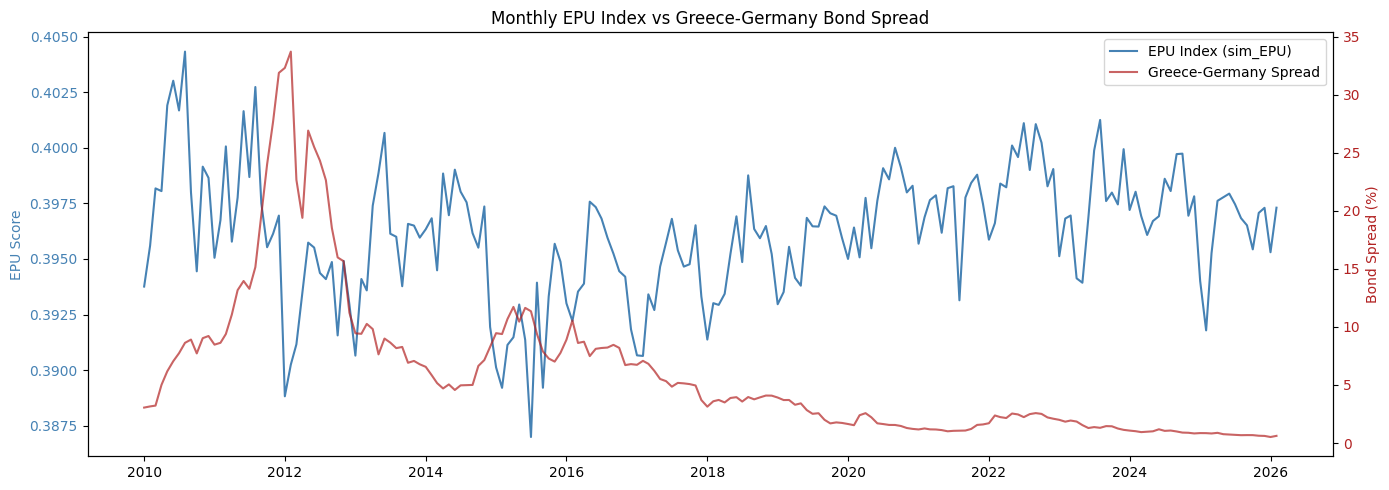

In [42]:
# Plot EPU index vs Bond Spread over time
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(merged["month_dt"], merged["sim_EPU"], color="steelblue", label="EPU Index (sim_EPU)")
ax1.set_ylabel("EPU Score", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

ax2 = ax1.twinx()
ax2.plot(merged["month_dt"], merged["Spread"], color="firebrick", alpha=0.7, label="Greece-Germany Spread")
ax2.set_ylabel("Bond Spread (%)", color="firebrick")
ax2.tick_params(axis="y", labelcolor="firebrick")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.title("Monthly EPU Index vs Greece-Germany Bond Spread")
plt.tight_layout()
plt.show()


In [43]:
import statsmodels.api as sm

X = merged[[f"sim_{cat}" for cat in cats]]
X_const = sm.add_constant(X)
model = sm.OLS(merged["Spread"], X_const).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                 Spread   R-squared:                       0.587
Model:                            OLS   Adj. R-squared:                  0.581
Method:                 Least Squares   F-statistic:                     90.18
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           2.51e-36
Time:                        23:41:55   Log-Likelihood:                -548.88
No. Observations:                 194   AIC:                             1106.
Df Residuals:                     190   BIC:                             1119.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             206.2231     79.691     

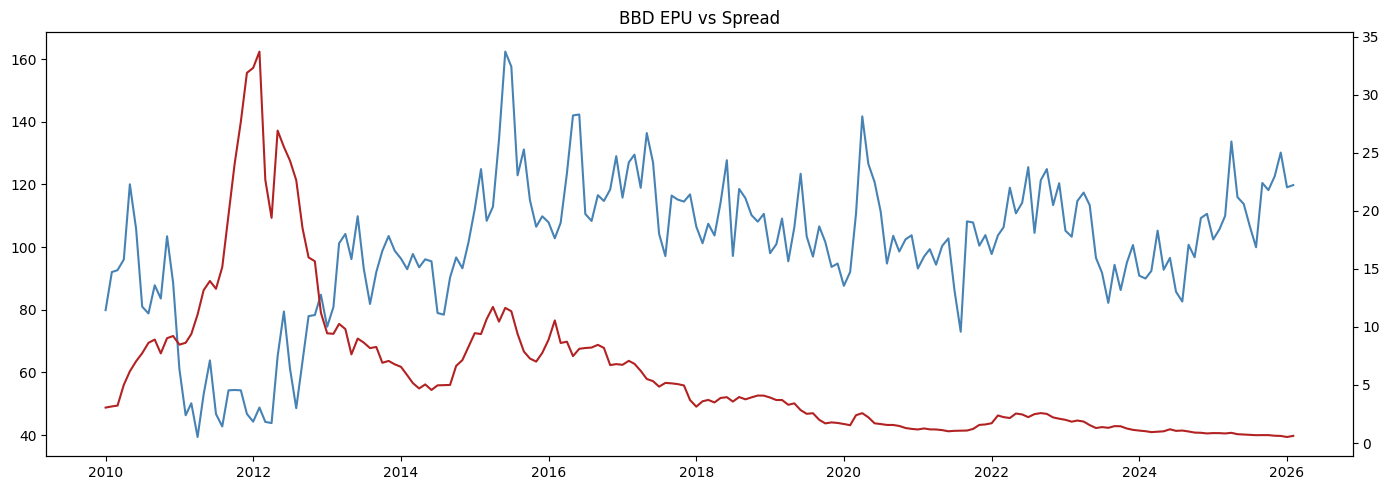

Pearson r: -0.5439  (p=0.0000)


In [45]:
monthly_bbd = df.groupby("month").agg(
    total     = ("content", "size"),
    epu_count = ("hit_ALL", "sum"),
).reset_index()

prop = monthly_bbd["epu_count"] / monthly_bbd["total"]
monthly_bbd["EPU_index"] = prop / prop.mean() * 100
monthly_bbd["month_dt"] = monthly_bbd["month"].dt.to_timestamp()

merged_bbd = monthly_bbd.merge(bonds_monthly, on="month", how="inner")

# Plot
fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(merged_bbd["month_dt"], merged_bbd["EPU_index"], color="steelblue", label="EPU Index")
ax2 = ax1.twinx()
ax2.plot(merged_bbd["month_dt"], merged_bbd["Spread"], color="firebrick", label="Spread")
plt.title("BBD EPU vs Spread")
plt.tight_layout(); plt.show()

r, p = stats.pearsonr(merged_bbd["EPU_index"], merged_bbd["Spread"])
print(f"Pearson r: {r:.4f}  (p={p:.4f})")


In [46]:
yearly = df.groupby(
    pd.to_datetime(df["date"], format="%m/%d/%Y").dt.year
).size()
print(yearly)


date
2010     63073
2011    127404
2012    132289
2013     90424
2014     96233
2015     85006
2016     73671
2017     66170
2018     63843
2019     60554
2020     77961
2021     74105
2022     70029
2023     62529
2024     62715
2025     58118
2026      9171
dtype: int64
